# Chapitre 8 (suite) — Calibration et Simulation Hull-White
### Mémoire M2 ISF — Modélisation du Spread de Taux

**Version Colab — aucun fichier local nécessaire**

Ce notebook couvre :
1. Téléchargement de la courbe swap EUR actuelle
2. Calibration kappa et sigma par MLE (même logique que Vasicek)
3. Calcul du shift alpha(t) depuis la courbe forward
4. Simulation Monte Carlo Hull-White
5. Comparaison Vasicek vs Hull-White

---

**Rappel fondamental :**
- kappa et sigma → MLE sur historique Euribor (comme Vasicek)
- theta(t) → PAS de MLE, calculé analytiquement depuis la courbe forward

## 0. Imports

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.interpolate import interp1d
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
np.random.seed(42)
print('OK imports')

OK imports


## 1. Téléchargement des données

In [ ]:
def fetch_ecb(series_key, name, start='2000-01-01'):
    flow, key = series_key.split('/', 1)
    url = (
        f'https://data-api.ecb.europa.eu/service/data/{flow}/{key}'
        f'?startPeriod={start}&format=csvdata'
    )
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(StringIO(r.text))
        df['date'] = pd.to_datetime(df['TIME_PERIOD'])
        df = df.set_index('date').sort_index()
        series = pd.to_numeric(df['OBS_VALUE'], errors='coerce')
        series.name = name
        series = series.resample('ME').last().dropna()
        print(f'  OK {name} : {len(series)} obs')
        return series
    except Exception as e:
        print(f'  ERREUR {name} : {e}')
        return None

print('Telechargement...')
euribor  = fetch_ecb('FM/M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA', 'Euribor_3M') / 100
swap_1y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y',  'Swap_1Y')  / 100
swap_2y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y',  'Swap_2Y')  / 100
swap_3y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y',  'Swap_3Y')  / 100
swap_5y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y',  'Swap_5Y')  / 100
swap_7y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_7Y',  'Swap_7Y')  / 100
swap_10y = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y', 'Swap_10Y') / 100
print('Tout telecharge !')

Telechargement...
  OK Euribor_3M : 318 obs
  OK Swap_1Y : 263 obs
  OK Swap_2Y : 263 obs
  OK Swap_3Y : 263 obs
  OK Swap_5Y : 263 obs
  OK Swap_7Y : 263 obs
  OK Swap_10Y : 263 obs
Tout telecharge !


## 2. Courbe de taux actuelle + taux forwards

On prend les dernières valeurs disponibles pour construire
la courbe de taux d'aujourd'hui, puis on calcule les taux
forwards instantanés f(0,t) par différentiation numérique :

```
f(0,t) = r(0,t) + t * dr(0,t)/dt
```

Courbe actuelle :
   3M : 2.3390%
   1Y : 2.6193%
   2Y : 2.7296%
   3Y : 2.7653%
   5Y : 2.8453%
   7Y : 2.9679%
  10Y : 3.1658%


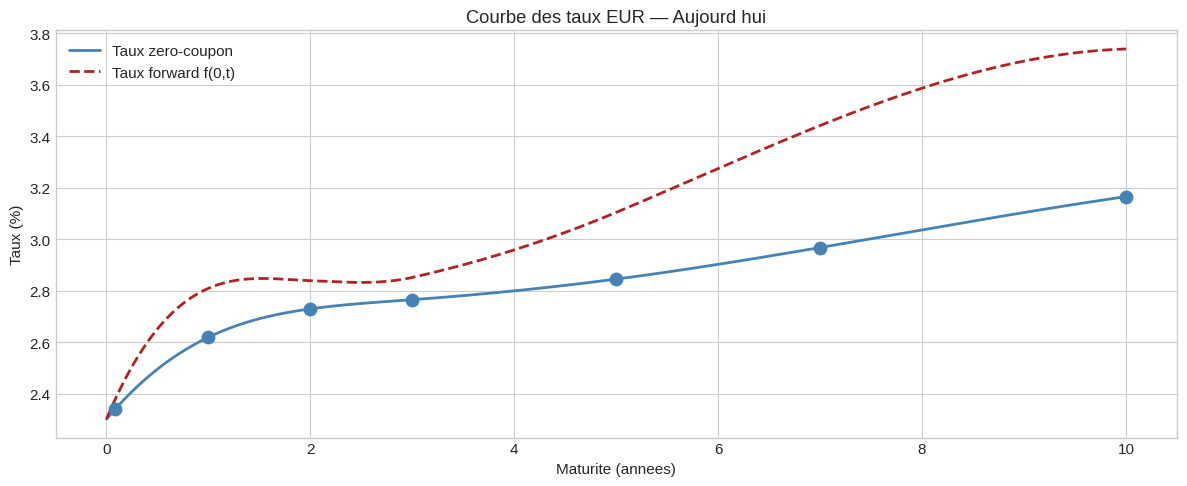

In [ ]:
# Courbe de taux actuelle
maturities_obs = np.array([1/12, 1, 2, 3, 5, 7, 10])
zero_rates_obs = np.array([
    float(euribor.iloc[-1]),
    float(swap_1y.iloc[-1]),
    float(swap_2y.iloc[-1]),
    float(swap_3y.iloc[-1]),
    float(swap_5y.iloc[-1]),
    float(swap_7y.iloc[-1]),
    float(swap_10y.iloc[-1]),
])

# Interpolation cubique pour courbe continue
curve_interp = interp1d(maturities_obs, zero_rates_obs,
                        kind='cubic', fill_value='extrapolate')
maturities_fine = np.linspace(0.001, 10, 1000)
zero_rates_fine = curve_interp(maturities_fine)

# Taux forwards : f(0,t) = r(t) + t * dr/dt
dr_dt = np.gradient(zero_rates_fine, maturities_fine)
forward_rates = zero_rates_fine + maturities_fine * dr_dt

print('Courbe actuelle :')
labels = ['3M','1Y','2Y','3Y','5Y','7Y','10Y']
for lab, mat, rate in zip(labels, maturities_obs, zero_rates_obs):
    print(f'  {lab:>3} : {rate*100:.4f}%')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(maturities_fine, zero_rates_fine*100,
        color='steelblue', linewidth=2, label='Taux zero-coupon')
ax.plot(maturities_fine, forward_rates*100,
        color='firebrick', linewidth=2, linestyle='--',
        label='Taux forward f(0,t)')
ax.scatter(maturities_obs, zero_rates_obs*100,
           color='steelblue', s=80, zorder=5)
ax.set_title('Courbe des taux EUR — Aujourd hui')
ax.set_xlabel('Maturite (annees)')
ax.set_ylabel('Taux (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Calibration kappa et sigma par MLE

Exactement la même logique que Vasicek.
kappa et sigma capturent la dynamique historique des taux.

In [ ]:
def vasicek_neg_log_likelihood(params, rates, dt):
    kappa, theta, sigma = params
    if kappa <= 0 or sigma <= 0:
        return 1e10
    e_kdt  = np.exp(-kappa * dt)
    e_2kdt = np.exp(-2 * kappa * dt)
    mu  = rates[:-1] * e_kdt + theta * (1 - e_kdt)
    var = (sigma**2 / (2 * kappa)) * (1 - e_2kdt)
    if np.any(var <= 0):
        return 1e10
    return -np.sum(norm.logpdf(rates[1:], loc=mu, scale=np.sqrt(var)))

rates_arr = euribor.values
dt = 1/12

r_t, r_tm1 = rates_arr[1:], rates_arr[:-1]
b    = np.cov(r_t, r_tm1)[0,1] / np.var(r_tm1)
a    = r_t.mean() - b * r_tm1.mean()
k0   = max(-np.log(max(b, 1e-6)) / dt, 0.01)
th0  = a / (k0 * dt) if k0 > 0 else r_t.mean()
sig0 = max((r_t - a - b*r_tm1).std() / np.sqrt(dt), 0.001)

result = minimize(
    vasicek_neg_log_likelihood,
    x0=[k0, th0, sig0],
    args=(rates_arr, dt),
    method='L-BFGS-B',
    bounds=[(1e-4, 10.0), (-0.05, 0.15), (1e-4, 0.50)],
    options={'maxiter': 1000}
)

kappa_hw = result.x[0]
sigma_hw = result.x[2]

print('=' * 50)
print('  PARAMETRES HULL-WHITE')
print('=' * 50)
print(f'  kappa = {kappa_hw:.4f}  (MLE — dynamique historique)')
print(f'  sigma = {sigma_hw:.4f}  (MLE — dynamique historique)')
print(f'  theta(t) = analytique depuis courbe forward')
print('=' * 50)

  PARAMETRES HULL-WHITE
  kappa = 0.0564  (MLE — dynamique historique)
  sigma = 0.0051  (MLE — dynamique historique)
  theta(t) = analytique depuis courbe forward


## 4. Calcul du shift alpha(t)

```
alpha(t) = f(0,t) + sigma² / (2*kappa²) * (1 - exp(-kappa*t))²
```

- **f(0,t)** : taux forward de marché
- **Terme de convexité** : correction technique, faible sur court terme

**alpha(t) est la trajectoire moyenne imposée par le marché.**
Les simulations oscillent autour de alpha(t), pas autour de theta constant.

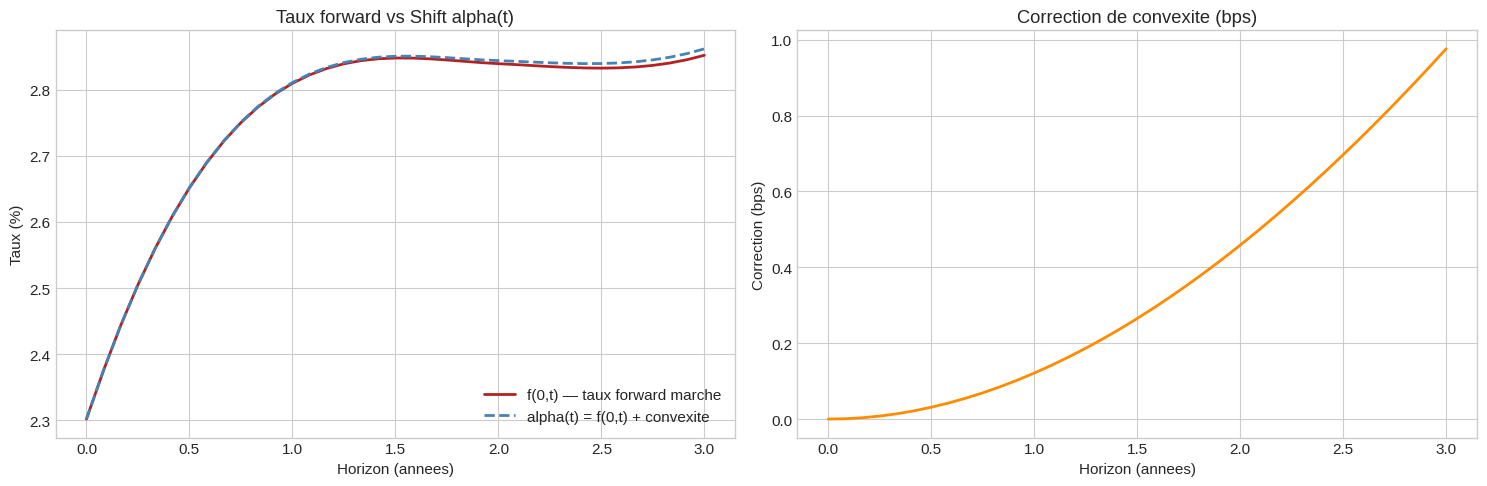

alpha(0)  = 2.3019%
alpha(1Y) = 2.8106%
alpha(3Y) = 2.8615%
Correction convexite max : 0.98 bps


In [ ]:
T_sim   = 3
N_steps = 36
dt_sim  = T_sim / N_steps
t_grid  = np.linspace(0, T_sim, N_steps + 1)

# Interpolation des forwards sur la grille de simulation
fwd_grid = np.interp(t_grid, maturities_fine, forward_rates)

# Calcul de alpha(t)
convexity = (sigma_hw**2 / (2 * kappa_hw**2)) * (1 - np.exp(-kappa_hw * t_grid))**2
alpha = fwd_grid + convexity

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(t_grid, fwd_grid*100, color='firebrick', linewidth=2,
        label='f(0,t) — taux forward marche')
ax.plot(t_grid, alpha*100, color='steelblue', linewidth=2,
        linestyle='--', label='alpha(t) = f(0,t) + convexite')
ax.set_title('Taux forward vs Shift alpha(t)')
ax.set_xlabel('Horizon (annees)')
ax.set_ylabel('Taux (%)')
ax.legend()

ax = axes[1]
ax.plot(t_grid, convexity*10000, color='darkorange', linewidth=2)
ax.set_title('Correction de convexite (bps)')
ax.set_xlabel('Horizon (annees)')
ax.set_ylabel('Correction (bps)')

plt.tight_layout()
plt.show()

print(f'alpha(0)  = {alpha[0]*100:.4f}%')
print(f'alpha(1Y) = {alpha[12]*100:.4f}%')
print(f'alpha(3Y) = {alpha[-1]*100:.4f}%')
print(f'Correction convexite max : {convexity.max()*10000:.2f} bps')

## 5. Simulation Monte Carlo Hull-White

Décomposition en deux étapes :

**1.** Simuler x(t) = processus Vasicek centré en zéro (solution exacte)
```
x(t+dt) = x(t) * exp(-kappa*dt) + sigma*sqrt((1-exp(-2k*dt))/(2k)) * Z
```

**2.** Reconstruire r(t) = x(t) + alpha(t)

In [ ]:
def simulate_hull_white(kappa, sigma, alpha, t_grid, r0, N_paths):
    N_steps = len(t_grid) - 1
    dt_s    = t_grid[1] - t_grid[0]

    x_paths = np.zeros((N_steps + 1, N_paths))
    x_paths[0, :] = r0 - alpha[0]  # x(0) = r(0) - alpha(0)

    e_kdt     = np.exp(-kappa * dt_s)
    std_exact = sigma * np.sqrt((1 - np.exp(-2*kappa*dt_s)) / (2*kappa))

    for i in range(N_steps):
        Z = np.random.standard_normal(N_paths)
        x_paths[i+1, :] = x_paths[i, :] * e_kdt + std_exact * Z

    # r(t) = x(t) + alpha(t)
    r_paths = x_paths + alpha[:, np.newaxis]
    return r_paths

r0      = float(euribor.iloc[-1])
N_paths = 10000

paths_hw = simulate_hull_white(kappa_hw, sigma_hw, alpha, t_grid, r0, N_paths)

mean_hw = paths_hw.mean(axis=1)
p5_hw   = np.percentile(paths_hw, 5,  axis=1)
p25_hw  = np.percentile(paths_hw, 25, axis=1)
p75_hw  = np.percentile(paths_hw, 75, axis=1)
p95_hw  = np.percentile(paths_hw, 95, axis=1)

print(f'Simulation OK : {N_paths:,} trajectoires')
print(f'Verification propriete fondamentale :')
print(f'  Moyenne simulee a 1Y : {mean_hw[12]*100:.4f}%')
print(f'  alpha(1Y)            : {alpha[12]*100:.4f}%')
print(f'  Ecart               : {abs(mean_hw[12]-alpha[12])*10000:.2f} bps')
print(f'  => La moyenne suit exactement alpha(t) !')

Simulation OK : 10,000 trajectoires
Verification propriete fondamentale :
  Moyenne simulee a 1Y : 2.8494%
  alpha(1Y)            : 2.8106%
  Ecart               : 3.88 bps
  => La moyenne suit exactement alpha(t) !


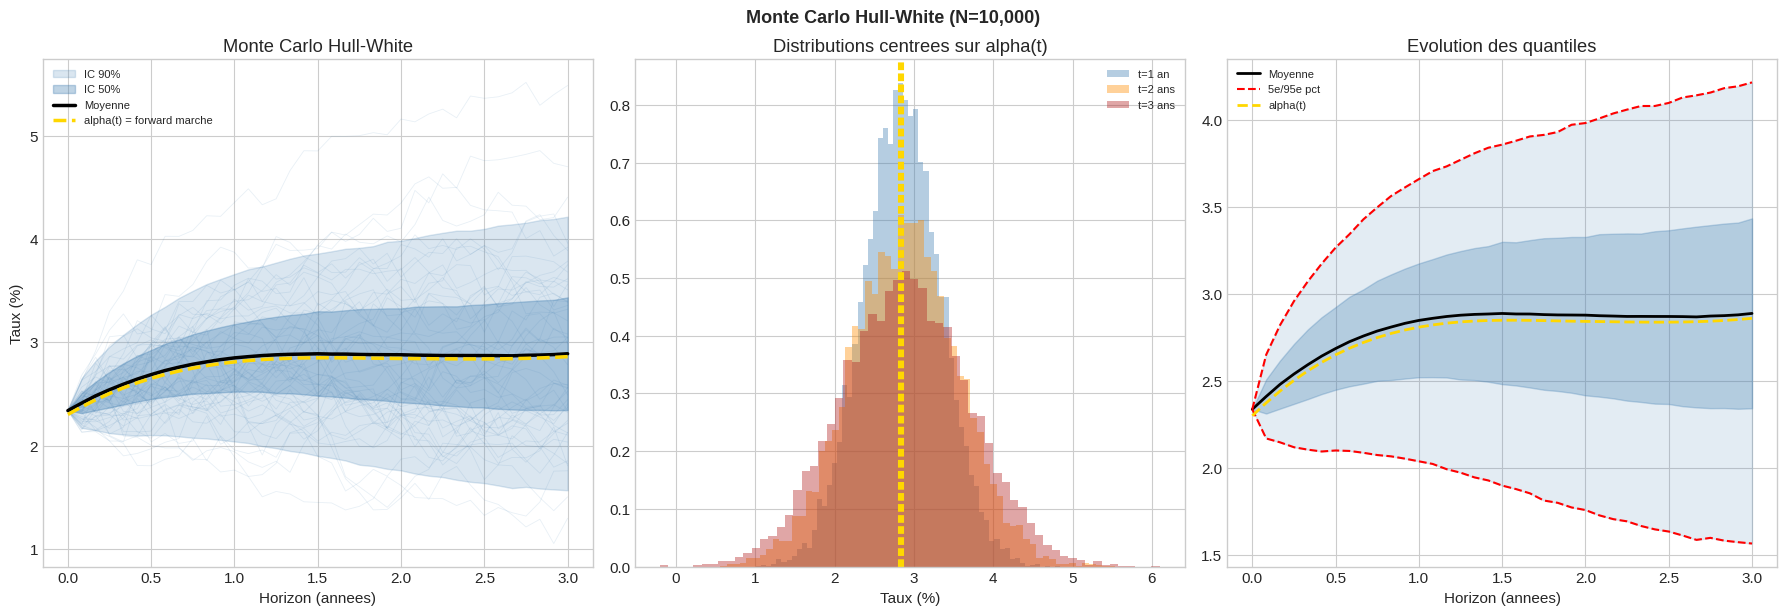

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
for j in range(50):
    ax.plot(t_grid, paths_hw[:, j]*100,
            alpha=0.12, linewidth=0.6, color='steelblue')
ax.fill_between(t_grid, p5_hw*100, p95_hw*100,
                alpha=0.2, color='steelblue', label='IC 90%')
ax.fill_between(t_grid, p25_hw*100, p75_hw*100,
                alpha=0.35, color='steelblue', label='IC 50%')
ax.plot(t_grid, mean_hw*100, 'black', linewidth=2.5, label='Moyenne')
ax.plot(t_grid, alpha*100, 'gold', linewidth=2.5,
        linestyle='--', label='alpha(t) = forward marche')
ax.set_title('Monte Carlo Hull-White')
ax.set_xlabel('Horizon (annees)')
ax.set_ylabel('Taux (%)')
ax.legend(fontsize=8)

ax = axes[1]
for t_idx, label, color in [
    (12, 't=1 an',  'steelblue'),
    (24, 't=2 ans', 'darkorange'),
    (36, 't=3 ans', 'firebrick')
]:
    ax.hist(paths_hw[t_idx,:]*100, bins=60, density=True,
            alpha=0.4, label=label, color=color)
for t_idx in [12, 24, 36]:
    ax.axvline(alpha[t_idx]*100, color='gold', linewidth=1.5, linestyle='--')
ax.set_title('Distributions centrees sur alpha(t)')
ax.set_xlabel('Taux (%)')
ax.legend(fontsize=8)

ax = axes[2]
ax.fill_between(t_grid, p5_hw*100, p95_hw*100, alpha=0.15, color='steelblue')
ax.fill_between(t_grid, p25_hw*100, p75_hw*100, alpha=0.30, color='steelblue')
ax.plot(t_grid, mean_hw*100, 'black', linewidth=2, label='Moyenne')
ax.plot(t_grid, p5_hw*100,  'red', linewidth=1.5, linestyle='--', label='5e/95e pct')
ax.plot(t_grid, p95_hw*100, 'red', linewidth=1.5, linestyle='--')
ax.plot(t_grid, alpha*100, 'gold', linewidth=2, linestyle='--', label='alpha(t)')
ax.set_title('Evolution des quantiles')
ax.set_xlabel('Horizon (annees)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle(f'Monte Carlo Hull-White (N={N_paths:,})',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 6. Comparaison Vasicek vs Hull-White

**Figure clé du mémoire** — montre pourquoi Hull-White est supérieur.

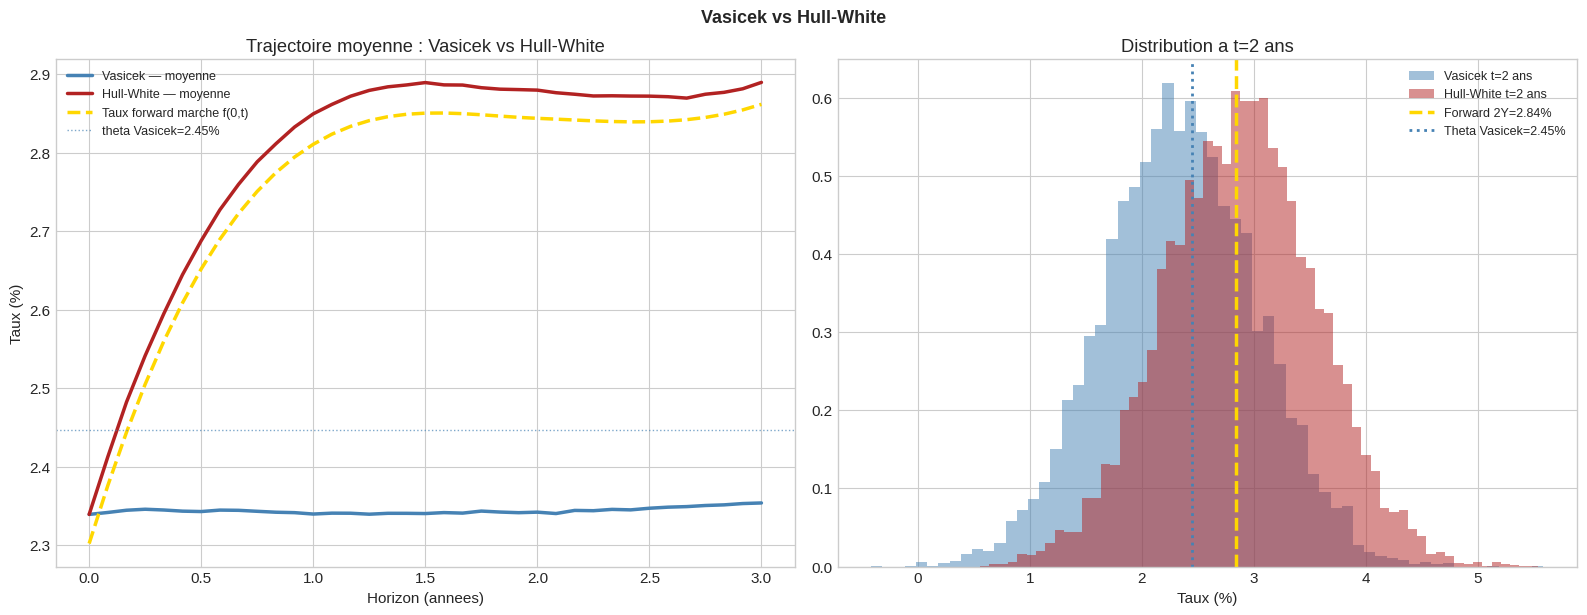

CONCLUSION :
  Vasicek a 2Y    : 2.3419% (converge vers theta=2.45%)
  Hull-White a 2Y : 2.8796% (suit forward marche=2.84%)
  Ecart HW/marche : 3.6 bps => coherent !
  Ecart V/marche  : 50.2 bps => incoherent !


In [ ]:
theta_v = float(euribor.values[-24:].mean())

def simulate_vasicek(r0, kappa, theta, sigma, t_grid, N_paths):
    N_steps = len(t_grid) - 1
    dt_s = t_grid[1] - t_grid[0]
    paths = np.zeros((N_steps + 1, N_paths))
    paths[0, :] = r0
    for i in range(N_steps):
        Z = np.random.standard_normal(N_paths)
        paths[i+1, :] = paths[i, :] + kappa*(theta - paths[i, :])*dt_s + sigma*np.sqrt(dt_s)*Z
    return paths

paths_v = simulate_vasicek(r0, kappa_hw, theta_v, sigma_hw, t_grid, N_paths)
mean_v  = paths_v.mean(axis=1)
p5_v    = np.percentile(paths_v, 5,  axis=1)
p95_v   = np.percentile(paths_v, 95, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(t_grid, mean_v*100,  color='steelblue', linewidth=2.5, label='Vasicek — moyenne')
ax.plot(t_grid, mean_hw*100, color='firebrick', linewidth=2.5, label='Hull-White — moyenne')
ax.plot(t_grid, alpha*100,   color='gold', linewidth=2.5,
        linestyle='--', label='Taux forward marche f(0,t)')
ax.axhline(theta_v*100, color='steelblue', linewidth=1,
           linestyle=':', alpha=0.7, label=f'theta Vasicek={theta_v*100:.2f}%')
ax.set_title('Trajectoire moyenne : Vasicek vs Hull-White')
ax.set_xlabel('Horizon (annees)')
ax.set_ylabel('Taux (%)')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(paths_v[24,:]*100,  bins=60, density=True, alpha=0.5,
        color='steelblue', label='Vasicek t=2 ans')
ax.hist(paths_hw[24,:]*100, bins=60, density=True, alpha=0.5,
        color='firebrick', label='Hull-White t=2 ans')
ax.axvline(alpha[24]*100, color='gold', linewidth=2.5,
           linestyle='--', label=f'Forward 2Y={alpha[24]*100:.2f}%')
ax.axvline(theta_v*100, color='steelblue', linewidth=2,
           linestyle=':', label=f'Theta Vasicek={theta_v*100:.2f}%')
ax.set_title('Distribution a t=2 ans')
ax.set_xlabel('Taux (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Vasicek vs Hull-White', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('CONCLUSION :')
print(f'  Vasicek a 2Y    : {mean_v[24]*100:.4f}% (converge vers theta={theta_v*100:.2f}%)')
print(f'  Hull-White a 2Y : {mean_hw[24]*100:.4f}% (suit forward marche={alpha[24]*100:.2f}%)')
print(f'  Ecart HW/marche : {abs(mean_hw[24]-alpha[24])*10000:.1f} bps => coherent !')
print(f'  Ecart V/marche  : {abs(mean_v[24]-alpha[24])*10000:.1f} bps => incoherent !')

## 7. Résumé

In [ ]:
print('=' * 60)
print('  RESUME CHAPITRE 8 — HULL-WHITE')
print('=' * 60)
print(f'  kappa = {kappa_hw:.4f}  (MLE sur Euribor)')
print(f'  sigma = {sigma_hw:.4f}  (MLE sur Euribor)')
print(f'  theta(t) = f(0,t) + correction convexite (analytique)')
print(f'\n  Propriete : E[r(t)] = alpha(t) = taux forward marche')
print(f'  => Hull-White est coherent avec les prix de marche !')
print(f'\n  Limites identifies :')
print(f'  - Un seul facteur brownien')
print(f'  - Distribution gaussienne => queues fines')
print(f'  - kappa, sigma constants')
print(f'  => Ces limites motivent DDPM/DDIM (Chapitre 9)')
print(f'\n  Prochaine etape => Chapitre 5 : XGBoost sur le spread')
print('=' * 60)

  RESUME CHAPITRE 8 — HULL-WHITE
  kappa = 0.0564  (MLE sur Euribor)
  sigma = 0.0051  (MLE sur Euribor)
  theta(t) = f(0,t) + correction convexite (analytique)

  Propriete : E[r(t)] = alpha(t) = taux forward marche
  => Hull-White est coherent avec les prix de marche !

  Limites identifies :
  - Un seul facteur brownien
  - Distribution gaussienne => queues fines
  - kappa, sigma constants
  => Ces limites motivent DDPM/DDIM (Chapitre 9)

  Prochaine etape => Chapitre 5 : XGBoost sur le spread
